In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Training_Input/ISIC_0012706.jpg
/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Training_Input/ISIC_0010192.jpg
/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Training_Input/ISIC_0010017.jpg
/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Training_Input/ISIC_0013000.jpg
/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Training_Input/ISIC_0013166.jpg
/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Training_Input/ISIC_0003308.jpg
/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Training_Input/ISIC_0012332.jpg
/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Training_Input/ISIC_0014291.jpg
/kaggle/

In [4]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


In [5]:
from pathlib import Path

image_dir = Path("/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Training_Input")
mask_dir = Path("/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1_Training_GroundTruth")

image_files = sorted(list(image_dir.glob("*.jpg")))
mask_files = sorted(list(mask_dir.glob("*.png")))

print("Number of images:", len(image_files))
print("Number of masks:", len(mask_files))

print("Example image:", image_files[0])
print("Example mask:", mask_dir / f"{image_files[0].stem}_segmentation.png")
print("Mask exists:", (mask_dir / f"{image_files[0].stem}_segmentation.png").exists())

Number of images: 2594
Number of masks: 2594
Example image: /kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Training_Input/ISIC_0000000.jpg
Example mask: /kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1_Training_GroundTruth/ISIC_0000000_segmentation.png
Mask exists: True


Image size: (1022, 767)
Mask size: (1022, 767)


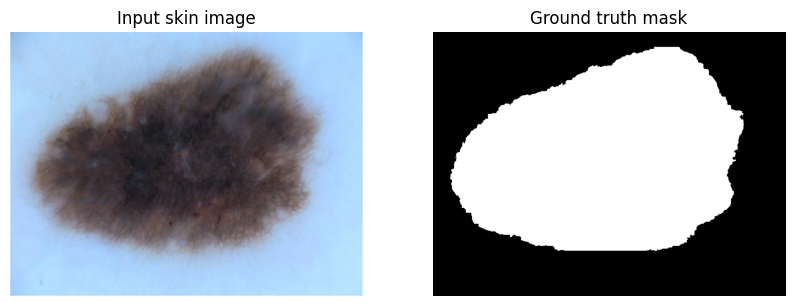

In [6]:
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

image_dir = Path("/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Training_Input")
mask_dir = Path("/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1_Training_GroundTruth")

img_path = image_dir / "ISIC_0000000.jpg"
mask_path = mask_dir / "ISIC_0000000_segmentation.png"

img = Image.open(img_path)
mask = Image.open(mask_path)

print("Image size:", img.size)
print("Mask size:", mask.size)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Input skin image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Ground truth mask")
plt.axis("off")

plt.show()

In [7]:
!git clone https://github.com/milesial/Pytorch-UNet.git /kaggle/working/Pytorch-UNet

Cloning into '/kaggle/working/Pytorch-UNet'...
remote: Enumerating objects: 618, done.
remote: Total 618 (delta 0), reused 0 (delta 0), pack-reused 618 (from 1)
Receiving objects: 100% (618/618), 47.42 MiB | 30.97 MiB/s, done.
Resolving deltas: 100% (338/338), done.


In [8]:
import os

print(os.listdir("/kaggle/working"))

['Pytorch-UNet', '.virtual_documents']


In [9]:
import os

os.chdir("/kaggle/working/Pytorch-UNet")
print("Current folder:", os.getcwd())
print(os.listdir())

Current folder: /kaggle/working/Pytorch-UNet
['.gitignore', 'LICENSE', 'Dockerfile', 'hubconf.py', 'unet', 'predict.py', 'data', 'README.md', 'scripts', 'evaluate.py', '.github', '.git', 'requirements.txt', 'train.py', 'utils']


In [10]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 56.2 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 116.3 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [11]:
!pip install wandb


In [12]:
import torch
import numpy
import matplotlib
import PIL
import tqdm

print("torch:", torch.__version__)
print("numpy:", numpy.__version__)
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

torch: 2.10.0+cu128
numpy: 2.4.6
GPU available: True
GPU name: Tesla T4


In [13]:
from pathlib import Path
import shutil

image_dir = Path("/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Training_Input")
mask_dir = Path("/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1_Training_GroundTruth")

out_img_dir = Path("/kaggle/working/Pytorch-UNet/data/imgs")
out_mask_dir = Path("/kaggle/working/Pytorch-UNet/data/masks")

shutil.rmtree(out_img_dir, ignore_errors=True)
shutil.rmtree(out_mask_dir, ignore_errors=True)

out_img_dir.mkdir(parents=True, exist_ok=True)
out_mask_dir.mkdir(parents=True, exist_ok=True)

image_files = sorted(list(image_dir.glob("*.jpg")))[:100]

count = 0

for img_path in image_files:
    image_id = img_path.stem
    mask_path = mask_dir / f"{image_id}_segmentation.png"

    if mask_path.exists():
        shutil.copy(img_path, out_img_dir / f"{image_id}.jpg")
        shutil.copy(mask_path, out_mask_dir / f"{image_id}.png")
        count += 1

print("Copied pairs:", count)
print("Images:", len(list(out_img_dir.glob('*'))))
print("Masks:", len(list(out_mask_dir.glob('*'))))

Copied pairs: 100
Images: 100
Masks: 100


In [14]:
!ls data/imgs | head
!ls data/masks | head

ISIC_0000000.jpg
ISIC_0000001.jpg
ISIC_0000003.jpg
ISIC_0000004.jpg
ISIC_0000006.jpg
ISIC_0000007.jpg
ISIC_0000008.jpg
ISIC_0000009.jpg
ISIC_0000011.jpg
ISIC_0000012.jpg
ISIC_0000000.png
ISIC_0000001.png
ISIC_0000003.png
ISIC_0000004.png
ISIC_0000006.png
ISIC_0000007.png
ISIC_0000008.png
ISIC_0000009.png
ISIC_0000011.png
ISIC_0000012.png


In [15]:
import os
os.environ["WANDB_MODE"] = "disabled"

In [16]:
!python train.py --epochs 2 --batch-size 2 --learning-rate 1e-4 --scale 0.5 --amp

INFO: Using device cuda
INFO: Network:
	3 input channels
	2 output channels (classes)
	Transposed conv upscaling
INFO: Creating dataset with 100 examples
INFO: Scanning mask files to determine unique values
  0%|                                                   | 0/100 [00:00<?, ?it/s]
INFO: Creating dataset with 100 examples
INFO: Scanning mask files to determine unique values
100%|█████████████████████████████████████████| 100/100 [00:01<00:00, 82.30it/s]
INFO: Unique mask values: [0, 255]
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
INFO: Starting training:
        Epochs:          2
        Batch size:      2
        Learning rate:   0.0001
        Training size:   90
        Validation size: 10
        Checkpoints:     True
        Device:          cuda
        Images scaling:  0.5
        Mixed Precision: True
    
/kaggle/working/Pytorch-UNet/train.py:80: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use

In [17]:
from pathlib import Path
from PIL import Image
import shutil

image_dir = Path("/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Training_Input")
mask_dir = Path("/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1_Training_GroundTruth")

out_img_dir = Path("/kaggle/working/Pytorch-UNet/data/imgs")
out_mask_dir = Path("/kaggle/working/Pytorch-UNet/data/masks")

shutil.rmtree(out_img_dir, ignore_errors=True)
shutil.rmtree(out_mask_dir, ignore_errors=True)

out_img_dir.mkdir(parents=True, exist_ok=True)
out_mask_dir.mkdir(parents=True, exist_ok=True)

image_files = sorted(list(image_dir.glob("*.jpg")))[:100]
target_size = (256, 256)

count = 0

for img_path in image_files:
    image_id = img_path.stem
    mask_path = mask_dir / f"{image_id}_segmentation.png"

    if not mask_path.exists():
        continue

    img = Image.open(img_path).convert("RGB")
    img = img.resize(target_size, Image.BILINEAR)
    img.save(out_img_dir / f"{image_id}.jpg")

    mask = Image.open(mask_path).convert("L")
    mask = mask.resize(target_size, Image.NEAREST)
    mask = mask.point(lambda p: 255 if p > 127 else 0)
    mask.save(out_mask_dir / f"{image_id}.png")

    count += 1

print("Saved resized pairs:", count)

Saved resized pairs: 100


Recreate resized 256×256 dataset

In [18]:
from pathlib import Path
from PIL import Image

img_dir = Path("/kaggle/working/Pytorch-UNet/data/imgs")
mask_dir = Path("/kaggle/working/Pytorch-UNet/data/masks")

img_sizes = set()
mask_sizes = set()

for p in img_dir.glob("*"):
    img_sizes.add(Image.open(p).size)

for p in mask_dir.glob("*"):
    mask_sizes.add(Image.open(p).size)

print("Image sizes:", img_sizes)
print("Mask sizes:", mask_sizes)

Image sizes: {(256, 256)}
Mask sizes: {(256, 256)}


In [19]:
!WANDB_MODE=disabled WANDB_DISABLED=true python train.py --epochs 2 --batch-size 2 --learning-rate 1e-4 --scale 1 --amp

INFO: Using device cuda
INFO: Network:
	3 input channels
	2 output channels (classes)
	Transposed conv upscaling
INFO: Creating dataset with 100 examples
INFO: Scanning mask files to determine unique values
  0%|                                                   | 0/100 [00:00<?, ?it/s]
INFO: Creating dataset with 100 examples
INFO: Scanning mask files to determine unique values
100%|████████████████████████████████████████| 100/100 [00:00<00:00, 906.58it/s]
INFO: Unique mask values: [0, 255]
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
INFO: Starting training:
        Epochs:          2
        Batch size:      2
        Learning rate:   0.0001
        Training size:   90
        Validation size: 10
        Checkpoints:     True
        Device:          cuda
        Images scaling:  1.0
        Mixed Precision: True
    
/kaggle/working/Pytorch-UNet/train.py:80: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use

In [20]:
!ls checkpoints

checkpoint_epoch1.pth  checkpoint_epoch2.pth


In [21]:
!python predict.py \
  --model checkpoints/checkpoint_epoch1.pth \
  --input data/imgs/ISIC_0000000.jpg \
  --output prediction.png

INFO: Loading model checkpoints/checkpoint_epoch1.pth
INFO: Using device cuda
INFO: Model loaded!
INFO: Predicting image data/imgs/ISIC_0000000.jpg ...
INFO: Mask saved to prediction.png


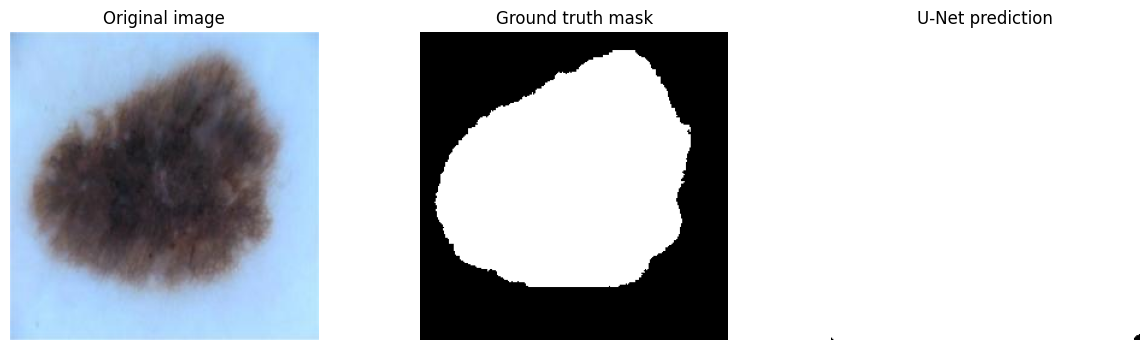

In [22]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("data/imgs/ISIC_0000000.jpg")
mask = Image.open("data/masks/ISIC_0000000.png")
pred = Image.open("prediction.png")

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("Ground truth mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred, cmap="gray")
plt.title("U-Net prediction")
plt.axis("off")

plt.show()

In [23]:
!WANDB_MODE=disabled WANDB_DISABLED=true python train.py --epochs 5 --batch-size 2 --learning-rate 1e-5 --scale 1

INFO: Using device cuda
INFO: Network:
	3 input channels
	2 output channels (classes)
	Transposed conv upscaling
INFO: Creating dataset with 100 examples
INFO: Scanning mask files to determine unique values
  0%|                                                   | 0/100 [00:00<?, ?it/s]
INFO: Creating dataset with 100 examples
INFO: Scanning mask files to determine unique values
100%|████████████████████████████████████████| 100/100 [00:00<00:00, 905.66it/s]
INFO: Unique mask values: [0, 255]
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
INFO: Starting training:
        Epochs:          5
        Batch size:      2
        Learning rate:   1e-05
        Training size:   90
        Validation size: 10
        Checkpoints:     True
        Device:          cuda
        Images scaling:  1.0
        Mixed Precision: False
    
/kaggle/working/Pytorch-UNet/train.py:80: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use

In [24]:
!ls checkpoints

checkpoint_epoch1.pth  checkpoint_epoch3.pth  checkpoint_epoch5.pth
checkpoint_epoch2.pth  checkpoint_epoch4.pth


In [25]:
!python predict.py \
  --model checkpoints/checkpoint_epoch5.pth \
  --input data/imgs/ISIC_0000000.jpg \
  --output prediction_epoch5.png

INFO: Loading model checkpoints/checkpoint_epoch5.pth
INFO: Using device cuda
INFO: Model loaded!
INFO: Predicting image data/imgs/ISIC_0000000.jpg ...
INFO: Mask saved to prediction_epoch5.png


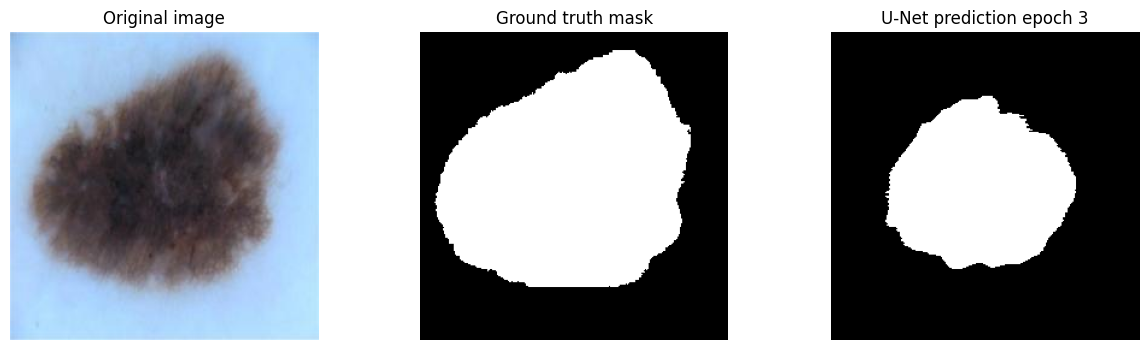

In [26]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("data/imgs/ISIC_0000000.jpg")
mask = Image.open("data/masks/ISIC_0000000.png")
pred = Image.open("prediction_epoch5.png")

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("Ground truth mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred, cmap="gray")
plt.title("U-Net prediction epoch 3")
plt.axis("off")

plt.show()

In [27]:
from pathlib import Path
from PIL import Image
import shutil

# Original ISIC dataset paths
image_dir = Path("/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Training_Input")
mask_dir = Path("/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1_Training_GroundTruth")

# Pytorch-UNet expected folders
out_img_dir = Path("/kaggle/working/Pytorch-UNet/data/imgs")
out_mask_dir = Path("/kaggle/working/Pytorch-UNet/data/masks")

# Clean previous 100-image data
shutil.rmtree(out_img_dir, ignore_errors=True)
shutil.rmtree(out_mask_dir, ignore_errors=True)

out_img_dir.mkdir(parents=True, exist_ok=True)
out_mask_dir.mkdir(parents=True, exist_ok=True)

# Use 500 images now
image_files = sorted(list(image_dir.glob("*.jpg")))[:500]

target_size = (256, 256)
count = 0

for img_path in image_files:
    image_id = img_path.stem
    mask_path = mask_dir / f"{image_id}_segmentation.png"

    if not mask_path.exists():
        continue

    # Resize image
    img = Image.open(img_path).convert("RGB")
    img = img.resize(target_size, Image.BILINEAR)
    img.save(out_img_dir / f"{image_id}.jpg")

    # Resize mask
    mask = Image.open(mask_path).convert("L")
    mask = mask.resize(target_size, Image.NEAREST)
    mask = mask.point(lambda p: 255 if p > 127 else 0)
    mask.save(out_mask_dir / f"{image_id}.png")

    count += 1

print("Saved resized pairs:", count)
print("Images:", len(list(out_img_dir.glob('*'))))
print("Masks:", len(list(out_mask_dir.glob('*'))))

Saved resized pairs: 500
Images: 500
Masks: 500


In [28]:
from pathlib import Path
from PIL import Image

img_dir = Path("/kaggle/working/Pytorch-UNet/data/imgs")
mask_dir = Path("/kaggle/working/Pytorch-UNet/data/masks")

img_sizes = set()
mask_sizes = set()

for p in img_dir.glob("*"):
    img_sizes.add(Image.open(p).size)

for p in mask_dir.glob("*"):
    mask_sizes.add(Image.open(p).size)

print("Image sizes:", img_sizes)
print("Mask sizes:", mask_sizes)

Image sizes: {(256, 256)}
Mask sizes: {(256, 256)}


In [29]:
!rm -rf checkpoints
!mkdir checkpoints
!ls checkpoints

In [30]:
!WANDB_MODE=disabled WANDB_DISABLED=true python train.py --epochs 10 --batch-size 2 --learning-rate 1e-5 --scale 1

INFO: Using device cuda
INFO: Network:
	3 input channels
	2 output channels (classes)
	Transposed conv upscaling
INFO: Creating dataset with 500 examples
INFO: Scanning mask files to determine unique values
  0%|                                                   | 0/500 [00:00<?, ?it/s]
INFO: Creating dataset with 500 examples
INFO: Scanning mask files to determine unique values
100%|███████████████████████████████████████| 500/500 [00:00<00:00, 1034.77it/s]
INFO: Unique mask values: [0, 255]
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
INFO: Starting training:
        Epochs:          10
        Batch size:      2
        Learning rate:   1e-05
        Training size:   450
        Validation size: 50
        Checkpoints:     True
        Device:          cuda
        Images scaling:  1.0
        Mixed Precision: False
    
/kaggle/working/Pytorch-UNet/train.py:80: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please u

In [31]:
!ls checkpoints

checkpoint_epoch10.pth	checkpoint_epoch4.pth  checkpoint_epoch8.pth
checkpoint_epoch1.pth	checkpoint_epoch5.pth  checkpoint_epoch9.pth
checkpoint_epoch2.pth	checkpoint_epoch6.pth
checkpoint_epoch3.pth	checkpoint_epoch7.pth


In [32]:
!python predict.py \
  --model checkpoints/checkpoint_epoch10.pth \
  --input data/imgs/ISIC_0000000.jpg \
  --output prediction_500_epoch10.png

INFO: Loading model checkpoints/checkpoint_epoch10.pth
INFO: Using device cuda
INFO: Model loaded!
INFO: Predicting image data/imgs/ISIC_0000000.jpg ...
INFO: Mask saved to prediction_500_epoch10.png


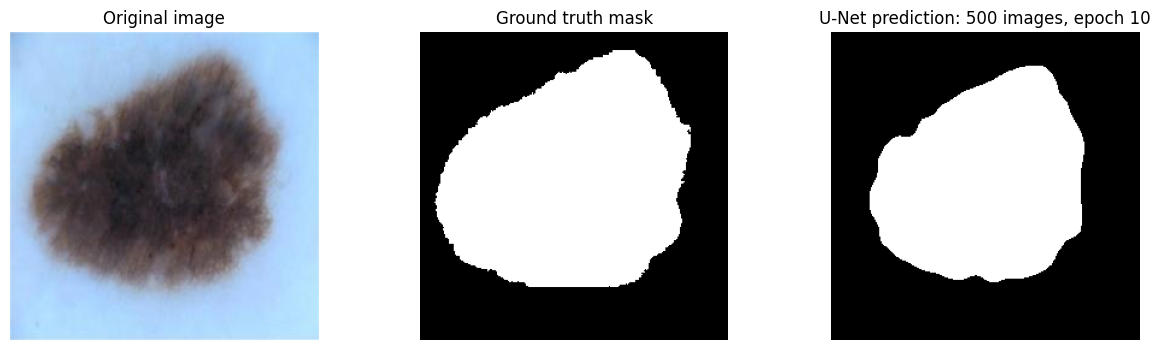

In [33]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("data/imgs/ISIC_0000000.jpg")
mask = Image.open("data/masks/ISIC_0000000.png")
pred = Image.open("prediction_500_epoch10.png")

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("Ground truth mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred, cmap="gray")
plt.title("U-Net prediction: 500 images, epoch 10")
plt.axis("off")

plt.show()

In [34]:
!python predict.py \
  --model checkpoints/checkpoint_epoch1.pth \
  --input data/imgs/ISIC_0000012.jpg \
  --output prediction_500_epoch1.png

INFO: Loading model checkpoints/checkpoint_epoch1.pth
INFO: Using device cuda
INFO: Model loaded!
INFO: Predicting image data/imgs/ISIC_0000012.jpg ...
INFO: Mask saved to prediction_500_epoch1.png


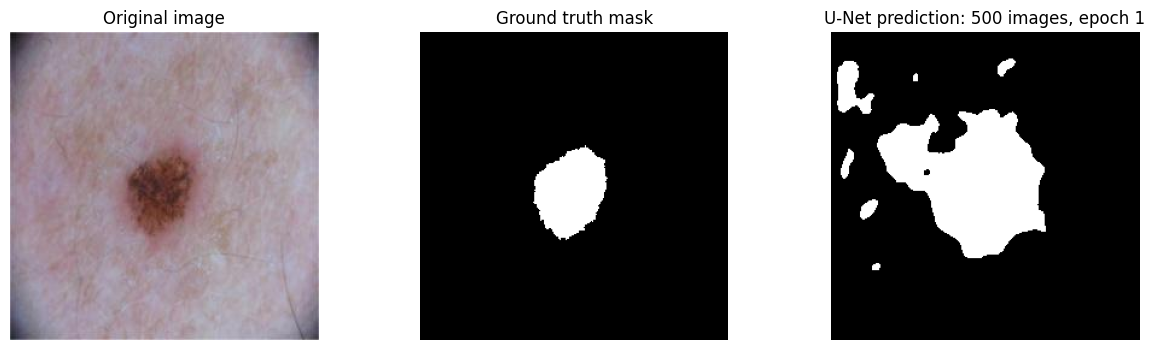

In [35]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("data/imgs/ISIC_0000012.jpg")
mask = Image.open("data/masks/ISIC_0000012.png")
pred = Image.open("prediction_500_epoch1.png")

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("Ground truth mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred, cmap="gray")
plt.title("U-Net prediction: 500 images, epoch 1")
plt.axis("off")

plt.show()

In [36]:
from pathlib import Path
from PIL import Image
import shutil

# Original ISIC dataset paths
image_dir = Path("/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Training_Input")
mask_dir = Path("/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1_Training_GroundTruth")

# Pytorch-UNet data folders
out_img_dir = Path("/kaggle/working/Pytorch-UNet/data/imgs")
out_mask_dir = Path("/kaggle/working/Pytorch-UNet/data/masks")

# Remove old 500-image data
shutil.rmtree(out_img_dir, ignore_errors=True)
shutil.rmtree(out_mask_dir, ignore_errors=True)

out_img_dir.mkdir(parents=True, exist_ok=True)
out_mask_dir.mkdir(parents=True, exist_ok=True)

# Use 1000 images
image_files = sorted(list(image_dir.glob("*.jpg")))[:1000]

target_size = (256, 256)
count = 0

for img_path in image_files:
    image_id = img_path.stem
    mask_path = mask_dir / f"{image_id}_segmentation.png"

    if not mask_path.exists():
        continue

    # Resize input image
    img = Image.open(img_path).convert("RGB")
    img = img.resize(target_size, Image.BILINEAR)
    img.save(out_img_dir / f"{image_id}.jpg")

    # Resize ground-truth mask
    mask = Image.open(mask_path).convert("L")
    mask = mask.resize(target_size, Image.NEAREST)
    mask = mask.point(lambda p: 255 if p > 127 else 0)
    mask.save(out_mask_dir / f"{image_id}.png")

    count += 1

print("Saved resized pairs:", count)
print("Images:", len(list(out_img_dir.glob('*'))))
print("Masks:", len(list(out_mask_dir.glob('*'))))

Saved resized pairs: 1000
Images: 1000
Masks: 1000


In [37]:
from pathlib import Path
from PIL import Image

img_dir = Path("/kaggle/working/Pytorch-UNet/data/imgs")
mask_dir = Path("/kaggle/working/Pytorch-UNet/data/masks")

img_sizes = set()
mask_sizes = set()

for p in img_dir.glob("*"):
    img_sizes.add(Image.open(p).size)

for p in mask_dir.glob("*"):
    mask_sizes.add(Image.open(p).size)

print("Image sizes:", img_sizes)
print("Mask sizes:", mask_sizes)

Image sizes: {(256, 256)}
Mask sizes: {(256, 256)}


In [38]:
!rm -rf checkpoints
!mkdir checkpoints
!ls checkpoints

In [39]:
!WANDB_MODE=disabled WANDB_DISABLED=true python train.py --epochs 10 --batch-size 2 --learning-rate 1e-5 --scale 1

INFO: Using device cuda
INFO: Network:
	3 input channels
	2 output channels (classes)
	Transposed conv upscaling
INFO: Creating dataset with 1000 examples
INFO: Scanning mask files to determine unique values
  0%|                                                  | 0/1000 [00:00<?, ?it/s]
INFO: Creating dataset with 1000 examples
INFO: Scanning mask files to determine unique values
100%|██████████████████████████████████████| 1000/1000 [00:01<00:00, 986.74it/s]
INFO: Unique mask values: [0, 255]
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
INFO: Starting training:
        Epochs:          10
        Batch size:      2
        Learning rate:   1e-05
        Training size:   900
        Validation size: 100
        Checkpoints:     True
        Device:          cuda
        Images scaling:  1.0
        Mixed Precision: False
    
/kaggle/working/Pytorch-UNet/train.py:80: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Pleas

In [40]:
!ls checkpoints

checkpoint_epoch10.pth	checkpoint_epoch4.pth  checkpoint_epoch8.pth
checkpoint_epoch1.pth	checkpoint_epoch5.pth  checkpoint_epoch9.pth
checkpoint_epoch2.pth	checkpoint_epoch6.pth
checkpoint_epoch3.pth	checkpoint_epoch7.pth


In [41]:
!python predict.py \
  --model checkpoints/checkpoint_epoch10.pth \
  --input data/imgs/ISIC_0000056.jpg \
  --output prediction_1000_epoch10.png

INFO: Loading model checkpoints/checkpoint_epoch10.pth
INFO: Using device cuda
INFO: Model loaded!
INFO: Predicting image data/imgs/ISIC_0000056.jpg ...
INFO: Mask saved to prediction_1000_epoch10.png


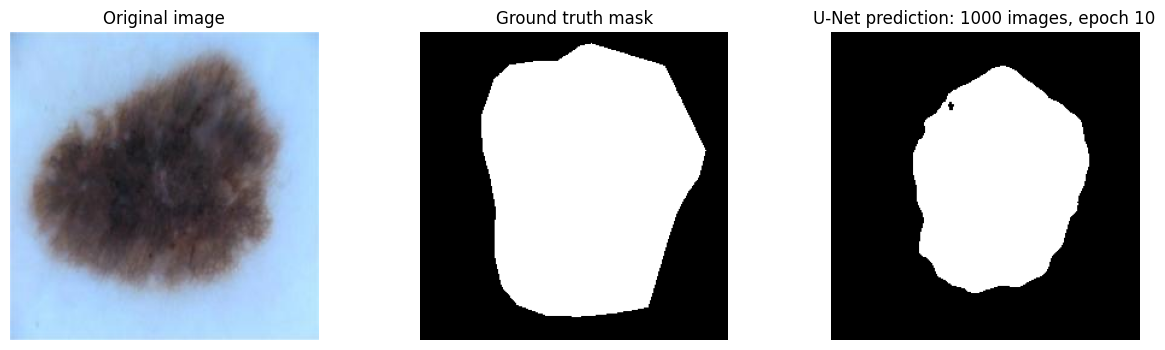

In [42]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("data/imgs/ISIC_0000000.jpg")
mask = Image.open("data/masks/ISIC_0000056.png")
pred = Image.open("prediction_1000_epoch10.png")

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("Ground truth mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred, cmap="gray")
plt.title("U-Net prediction: 1000 images, epoch 10")
plt.axis("off")

plt.show()

In [ ]:
from pathlib import Path
from PIL import Image
import shutil

# Original ISIC dataset paths
image_dir = Path("/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Training_Input")
mask_dir = Path("/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1_Training_GroundTruth")

# Pytorch-UNet data folders
out_img_dir = Path("/kaggle/working/Pytorch-UNet/data/imgs")
out_mask_dir = Path("/kaggle/working/Pytorch-UNet/data/masks")

# Remove old data
shutil.rmtree(out_img_dir, ignore_errors=True)
shutil.rmtree(out_mask_dir, ignore_errors=True)

out_img_dir.mkdir(parents=True, exist_ok=True)
out_mask_dir.mkdir(parents=True, exist_ok=True)

# Use full dataset
image_files = sorted(list(image_dir.glob("*.jpg")))

target_size = (256, 256)
count = 0

for img_path in image_files:
    image_id = img_path.stem
    mask_path = mask_dir / f"{image_id}_segmentation.png"

    if not mask_path.exists():
        continue

    # Resize image
    img = Image.open(img_path).convert("RGB")
    img = img.resize(target_size, Image.BILINEAR)
    img.save(out_img_dir / f"{image_id}.jpg")

    # Resize mask
    mask = Image.open(mask_path).convert("L")
    mask = mask.resize(target_size, Image.NEAREST)
    mask = mask.point(lambda p: 255 if p > 127 else 0)
    mask.save(out_mask_dir / f"{image_id}.png")

    count += 1

print("Saved resized pairs:", count)
print("Images:", len(list(out_img_dir.glob('*'))))
print("Masks:", len(list(out_mask_dir.glob('*'))))

In [44]:
from pathlib import Path
from PIL import Image

img_dir = Path("/kaggle/working/Pytorch-UNet/data/imgs")
mask_dir = Path("/kaggle/working/Pytorch-UNet/data/masks")

img_sizes = set()
mask_sizes = set()

for p in img_dir.glob("*"):
    img_sizes.add(Image.open(p).size)

for p in mask_dir.glob("*"):
    mask_sizes.add(Image.open(p).size)

print("Image sizes:", img_sizes)
print("Mask sizes:", mask_sizes)

Image sizes: {(256, 256)}
Mask sizes: {(256, 256)}


In [45]:
!rm -rf checkpoints
!mkdir checkpoints
!ls checkpoints

In [51]:
!WANDB_MODE=disabled WANDB_DISABLED=true python train.py --epochs 10 --batch-size 2 --learning-rate 1e-5 --scale 1

INFO: Using device cuda
INFO: Network:
	3 input channels
	2 output channels (classes)
	Transposed conv upscaling
INFO: Creating dataset with 1535 examples
INFO: Scanning mask files to determine unique values
  0%|                                                  | 0/1535 [00:00<?, ?it/s]
INFO: Creating dataset with 1535 examples
INFO: Scanning mask files to determine unique values
100%|██████████████████████████████████████| 1535/1535 [00:01<00:00, 840.65it/s]
INFO: Unique mask values: [0, 255]
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
INFO: Starting training:
        Epochs:          10
        Batch size:      2
        Learning rate:   1e-05
        Training size:   1382
        Validation size: 153
        Checkpoints:     True
        Device:          cuda
        Images scaling:  1.0
        Mixed Precision: False
    
/kaggle/working/Pytorch-UNet/train.py:80: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Plea

In [52]:
!ls checkpoints

checkpoint_epoch10.pth	checkpoint_epoch4.pth  checkpoint_epoch8.pth
checkpoint_epoch1.pth	checkpoint_epoch5.pth  checkpoint_epoch9.pth
checkpoint_epoch2.pth	checkpoint_epoch6.pth
checkpoint_epoch3.pth	checkpoint_epoch7.pth


In [ ]:
!python predict.py \
  --model checkpoints/checkpoint_epoch10.pth \
  --input data/imgs/ISIC_0000000.jpg \
  --output prediction_full_epoch10.png

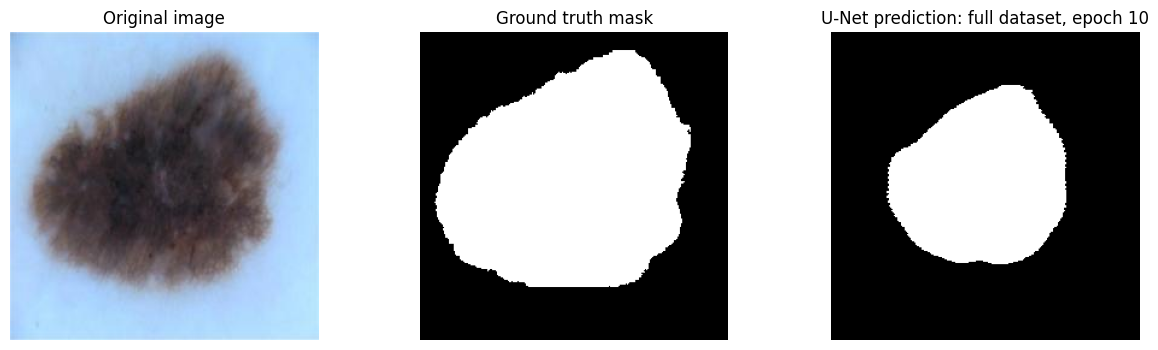

In [53]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("data/imgs/ISIC_0000000.jpg")
mask = Image.open("data/masks/ISIC_0000000.png")
pred = Image.open("prediction_full_epoch10.png")

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("Ground truth mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred, cmap="gray")
plt.title("U-Net prediction: full dataset, epoch 10")
plt.axis("off")

plt.show()